# TP6 : k plus proches voisins (KNN)

Importez les bibliothèques suivantes.

In [2]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA, la NMF, le MDS et l'Isomap. Le présent TP utilisant les résultats de ces derniers, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**), `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) et `NMF` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF

Importez le jeu de données Fashion-MNIST complet via la fonction `fetch_openml` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html)**). Nous travaillerons sur les 10 000 premières images et les 10 classes de vêtements correspondantes.

In [4]:
from sklearn.datasets import fetch_openml

X_full, y_full = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X_full[:10000]
y = y_full[:10000].astype(int)

print(f"Taille du dataset : {X.shape[0]} images de {X.shape[1]} pixels")
print(f"Classes présentes : {np.unique(y)}")

Taille du dataset : 10000 images de 784 pixels
Classes présentes : [0 1 2 3 4 5 6 7 8 9]


Les classes de vêtements sont étiquettées de la manière suivante :
- $0$ : T-shirt
- $1$ : Pantalon
- $2$ : Pull
- $3$ : Robe
- $4$ : Manteau
- $5$ : Sandale
- $6$ : Chemise
- $7$ : Basket
- $8$ : Sac
- $9$ : Bottine

---

## Introduction : de l'apprentissage non-supervisé à l'apprentissage supervisé

Jusqu'ici, tous les algorithmes que nous avons étudiés (K-means, PCA, NMF, MDS, Isomap) sont des méthodes d'apprentissage non-supervisé : ils cherchent une structure dans les données sans utiliser d'étiquettes. Nous avons par exemple regroupé les images en clusters et tenté de les interpréter a posteriori en comparant avec le vecteur `y` de vrais labels.

Nous entrons maintenant dans la partie d'apprentissage supervisé du cours. Cette fois, nous disposons dès le départ des étiquettes y pour une partie des données — le jeu d'entraînement `X_train`. L'objectif est d'apprendre, à partir de ces exemples étiquetés, une fonction capable de prédire l'étiquette de nouvelles données encore jamais vues — le jeu de test `X_test`.

Dans ce TP, nous allons implémenter l'algorithme des $k$ plus proches voisins (KNN). L'idée est intuitive : pour prédire la classe d'un nouvel exemple, on cherche les $k$ exemples d'entraînement qui lui ressemblent le plus au sens d'une distance, et on prédit la classe majoritaire parmi ces voisins.

Notez le lien fort avec ce que nous avons déjà fait : la notion de distance était déjà au cœur du K-clustering et du MDS.

## Construction de la classe MyKNN

Le but de ce TP est la création d'une classe permettant l'entraînement et la prédiction d'un modèle KNN. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [5]:
class MyKNN:
    def __init__(self, n_neighbors=5):
        self.k = n_neighbors
        
        # Attributs qui seront remplis lors de l'entraînement
        self.X_train = None
        self.y_train = None

print("Classe initialisée.")

Classe initialisée.


---

## Exercice 1 : distances entre un jeu d'entraînement et un jeu de test

Dans le TP5, nous avions construit une fonction `distances(data)` calculant la matrice de distances entre toutes les paires de points d'un même jeu de données. Ici, nous avons besoin de quelque chose de légèrement différent : calculer la distance entre chaque point de `X_test` et chaque point de `X_train`.

Formellement, si X_train est de taille $(n, p)$ et X_test de taille $(m, p)$, la matrice résultante $D$ doit être de taille $(m, n)$ avec :
$$D_{ij} = d(\text{X\_test}[i],\ \text{X\_train}[j])$$

Vous pouvez utiliser la même formule d'Al-Kashi que dans le TP5 :
$$d(x,y)^2 = \|x\|^2 + \|y\|^2 - 2\langle x,y \rangle$$

1. Construisez une fonction `cross_distances(X_train, X_test)` retournant cette matrice $D$ de taille $(m, n)$.

Note : comme dans le TP5, des erreurs d'approximation numérique peuvent produire de très petits nombres négatifs. Pensez à les ramener à zéro avant d'appliquer np.sqrt (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html)**).

In [6]:
def cross_distances(X_train, X_test):
    norms_test = np.sum(X_test**2, axis=1, keepdims=True)
    norms_train = np.sum(X_train**2, axis=1, keepdims=True).T  
    dot_products = X_test @ X_train.T 
    distances_squared = norms_test + norms_train - 2 * dot_products
    distances_squared = np.maximum(distances_squared, 0)
    return np.sqrt(distances_squared)

2. Vérifiez votre fonction sur un petit exemple. En prenant les 10 premières lignes de `X` à la fois comme `X_test` et comme  `X_train`, les distances d'un point à lui-même (la diagonale) doivent être nulles. Affichez cette diagonale.

In [7]:
print(cross_distances(X[:10], X[:10]))

[[   0.         3742.30690885 3408.91199652 3402.36388413 3552.55007002
  3208.04270545 3163.43120678 3566.33691622 3495.444893   3248.67588411]
 [3742.30690885    0.         3031.67907273 2548.17130507 2721.25577629
  2698.7328508  3804.17507484 3544.86671118 3879.93118496 4093.82486191]
 [3408.91199652 3031.67907273    0.         1371.01167026 2319.31347601
  2987.49476987 2409.26212771 4276.7272534  2043.50287497 2936.15224401]
 [3402.36388413 2548.17130507 1371.01167026    0.         2170.92560904
  2616.55728009 2819.8366974  3926.9946524  2512.55149201 3105.35038281]
 [3552.55007002 2721.25577629 2319.31347601 2170.92560904    0.
  2988.04986572 3487.500681   4075.99766928 3508.27578733 3901.84353864]
 [3208.04270545 2698.7328508  2987.49476987 2616.55728009 2988.04986572
     0.         3437.31304946 2560.29705308 3679.4139479  3692.04211785]
 [3163.43120678 3804.17507484 2409.26212771 2819.8366974  3487.500681
  3437.31304946    0.         4314.43090106 2702.4707214  3358.85426

---

## Exercice 2 : méthode fit

Contrairement aux algorithmes non-supervisés que nous avons vus, l'entraînement d'un KNN est extrêmement simple : il n'y a rien à calculer. Il s'agit uniquement de mémoriser le jeu d'entraînement X_train et les étiquettes associées y_train.

Ajoutez à la classe MyKNN une méthode `fit(self, X_train, y_train)` qui stocke X_train et y_train dans les attributs correspondants.

In [8]:
def fit(self,X_train,y_train):
    self.X_train= X_train
    self.y_train=y_train

MyKNN.fit=fit

---

## Exercice 3 : méthode predict

C'est le cœur de l'algorithme. Pour chaque point de `X_test`, la méthode `predict` doit :

1. Calculer sa distance à tous les points de `X_train` en utilisant cross_distances.
2. Identifier les indices des $k$ points d'entraînement les plus proches.
3. Récupérer les étiquettes `y_train` de ces $k$ voisins.
4. Prédire la classe majoritaire parmi ces $k$ étiquettes.

Ajoutez à la classe `MyKNN` une méthode `predict(self, X_test)` qui retourne le vecteur des prédictions d'étiquettes.

Indication : np.argsort (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)**) peut vous être utile pour trouver les indices des plus proches voisins. Pour le vote majoritaire, vous pouvez utiliser np.bincount (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html)**) et np.argmax (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)**). De plus, vous pouvez utilisez une boucle for sur la longueur de `X_test`.

In [9]:

def predict(self, X_test):
    distances = cross_distances(self.X_train, X_test)
    predictions = []
    
    for i in range(len(X_test)):
        nearest_indices = np.argsort(distances[i])[:self.k]
        nearest_labels = self.y_train[nearest_indices]
        predicted_label = np.argmax(np.bincount(nearest_labels))
        predictions.append(predicted_label)
    return np.array(predictions)

MyKNN.predict = predict

---

## Exercice 4 : méthode score

Ajoutez à la classe MyKNN une méthode `score(self, X_test, y_test)` qui retourne la précision (accuracy) du modèle sur le jeu de test : la proportion de prédictions correctes.

$$\text{accuracy} = \frac{\text{nombre de prédictions correctes}}{\text{nombre total de prédictions}}$$

In [10]:
def score(self, X_test, y_test):
    predictions = self.predict(X_test)
    return np.mean(predictions == y_test)

MyKNN.score = score

---

## Exercice 5 : premier test et matrice de confusion

Nous allons maintenant tester notre implémentation. Divisez le dataset en un jeu d'entraînement (80% des données) et un jeu de test (20% des données) en utilisant np.random.permutation (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html)**) pour mélanger aléatoirement les indices.

1. Entraînez un modèle `MyKNN` avec $k=5$ sur `X_train` et calculez sa précision sur `X_test`.

Note : le calcul peut prendre quelques dizaines de secondes, car il faut calculer les distances entre les 2000 points de test et les 8000 points d'entraînement dans un espace de dimension $784$.

In [11]:
np.random.seed(42)  
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

knn = MyKNN(n_neighbors=5)
knn.fit(X_train, y_train)
#precision
accuracy = knn.score(X_test, y_test)
print(f"Précision du modèle KNN (k=5) : {accuracy}")

Précision du modèle KNN (k=5) : 0.8165


2.  La matrice de confusion est un tableau carré de taille $C \times C$ où $C$ est le nombre de classes. La case $(i,j)$ contient le nombre d'exemples dont le vrai label est $i$ et dont le label prédit est $j$. Calculez et affichez la matrice de confusion à l'aide de pd.crosstab (**[documentation](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html)**) et sns.heatmap (**[documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html)**). Quelle interprétation peut-on donner à la diagonale ? Au reste de la matrice ? Quelles classes sont le plus souvent confondues entre elles ? Cela vous semble-t-il cohérent ?

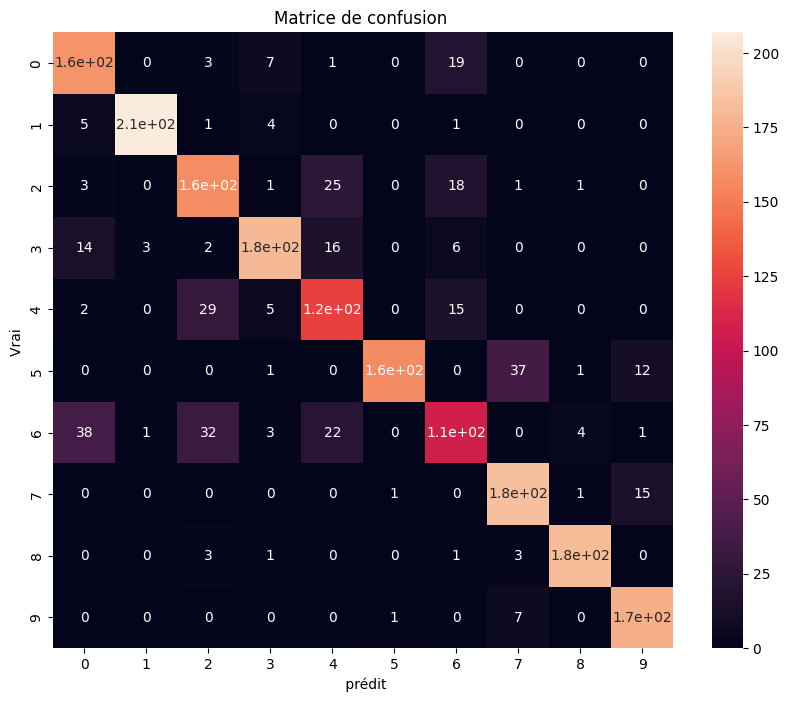

In [16]:
y_pred = knn.predict(X_test)
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Vrai '], colnames=[' prédit'])
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix,annot=True)
plt.title('Matrice de confusion ')
plt.show()

Écrivez votre interprétation ici.
La matrice de confusion montre que le modèle KNN avec k=5 atteint une précision de 81.65% sur le jeu de test. La diagonale représente les prédictions correctes : plus elle est remplie, meilleures sont les performances. Le reste de la matrice montre les confusions entre classes.

Les confusions les plus fréquentes concernent :
- Pulls (2) vs Manteaux (4) : ces deux vêtements ont des structures visuelles similaires, ce qui explique les erreurs de classification.
- Robes (3) vs Manteaux (4) : confusion logique car les deux sont des vêtements longs.
- Sandales (5) vs Baskets (7)** : les deux sont des chaussures, d'où une certaine ressemblance.
- T-shirts (0) vs Chemises (6) : deux vêtements haut du corps avec des motifs similaires.

Ces résultats sont cohérents : les confusions ne sont pas aléatoires mais regroupent des catégories visuellement ou sémantiquement proches. Le modèle fait preuve d'une compréhension raisonnable des similarités entre vêtements.

---

## Exercice bonus 1 : impact de la taille du jeu d'entraînement

Le KNN mémorise les données d'entraînement sans rien calculer dans la méthode fit. On pourrait donc penser que disposer de plus ou moins d'exemples ne change rien à l'algorithme en lui-même. Pourtant, la taille du jeu d'entraînement est un facteur déterminant pour la qualité des prédictions.

1. Construisez une fonction `test_train_size(n_train)` qui, pour un nombre d'exemples d'entraînement `n_train donné`, entraîne un `MyKNN` avec $k=5$ sur les `n_train` premiers exemples de `X_trainè  et retourne la précision sur `X_test`.

Appelez cette fonction pour les valeurs suivantes : $50, 100, 200, 500, 1000, 2000, 4000, 8000$. Tracez la courbe d'accuracy en fonction de `n_train`.

Note : veillez à utiliser le même jeu de test `X_test` à chaque fois, afin que les comparaisons soient équitables.

n_train = 50 : accuracy = 0.564
n_train = 100 : accuracy = 0.6145
n_train = 200 : accuracy = 0.712
n_train = 500 : accuracy = 0.7415
n_train = 1000 : accuracy = 0.7495
n_train = 2000 : accuracy = 0.7775
n_train = 4000 : accuracy = 0.8075
n_train = 8000 : accuracy = 0.8165


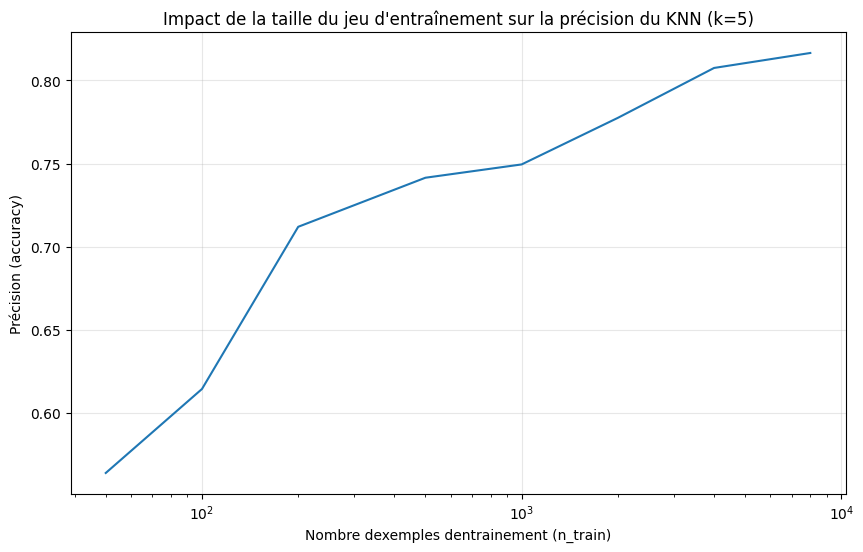

In [17]:
def test_train_size(n_train):
    knn_temp = MyKNN(n_neighbors=5)
    knn_temp.fit(X_train[:n_train], y_train[:n_train])
    return knn_temp.score(X_test, y_test)

# test
train_sizes = [50, 100, 200, 500, 1000, 2000, 4000, 8000]
accuracies = []

for n in train_sizes:
    acc = test_train_size(n)
    accuracies.append(acc)
    print(f"n_train = {n} : accuracy = {acc}")

# tracer la courbe
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, accuracies)
plt.xlabel('Nombre dexemples dentrainement (n_train)')
plt.ylabel('Précision (accuracy)')
plt.title('Impact de la taille du jeu d\'entraînement sur la précision du KNN (k=5)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

2. Décrivez la forme de la courbe. Y a-t-il un palier ? Que se passe-t-il pour de très petits jeux d'entraînement ? Cette courbe vous semble-t-elle converger ?

La courbe montre une croissance rapide puis un ralentissement progressif :

- Très petits jeux d'entraînement (50-200 exemples) : la précision est faible (~56-71%). Le modèle manque d'exemples pour bien représenter chaque classe.

- Croissance rapide (200-1000 exemples) : amélioration significative de ~71% à ~75%. Chaque nouvel exemple apporte beaucoup d'information.

- Ralentissement (1000-8000 exemples) : la courbe continue à croître mais plus lentement, atteignant ~81.65%. Les gains deviennent marginaux.

- Convergence apparente : la courbe tend vers un palier autour de 81-82%. Au-delà de 8000 exemples, on n'attendrait que peu d'amélioration. Cette limite peut être due à la complexité du problème (certaines classes se ressemblent beaucoup) ou aux limitations du KNN avec k=5.

    CCL : oui, la courbe semble converger. Les premiers exemples sont cruciaux, mais après un certain seuil, ajouter des données améliore peu les performances.


---

## Exercice bonus 2 : visualisation des erreurs

Pour mieux comprendre les limites du modèle, nous allons examiner les images mal classifiées par le KNN (k=5, 80% train). Pour chacune, nous allons également afficher ses 5 plus proches voisins dans le jeu d'entraînement, afin de comprendre pourquoi le modèle s'est trompé. Nous utiliserons la fonction `display_image`.

In [14]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Construisez une fonction `display_errors(knn, X_test, y_test, n_errors)` qui affiche les `n_errors premières` erreurs du modèle. Pour chaque erreur, affichez : 
- le vrai label de l'image, le label prédit et les labels des $k$ plus proches voisins,
- l'image mal classifiée et les images de ses $k$ plus proches voisins.

In [18]:
def display_errors(knn, X_test, y_test, n_errors):
    y_pred = knn.predict(X_test)
    error_indices = np.where(y_pred != y_test)[0][:n_errors]
    
    for idx in error_indices:
        distances = cross_distances(knn.X_train, X_test[idx:idx+1]).ravel()
        nearest_indices = np.argsort(distances)[:knn.k]
        nearest_labels = knn.y_train[nearest_indices]
        
        print(f"Vrai label: {y_test[idx]}, Prédit: {y_pred[idx]}, Voisins: {nearest_labels}")
        display_image([X_test[idx]] + list(knn.X_train[nearest_indices]))

Vrai label: 2, Prédit: 4, Voisins: [4 2 4 2 4]
Vrai label: 5, Prédit: 7, Voisins: [7 5 5 7 7]
Vrai label: 5, Prédit: 7, Voisins: [7 7 7 7 7]
Vrai label: 0, Prédit: 3, Voisins: [6 3 1 0 3]
Vrai label: 1, Prédit: 3, Voisins: [1 3 3 3 3]


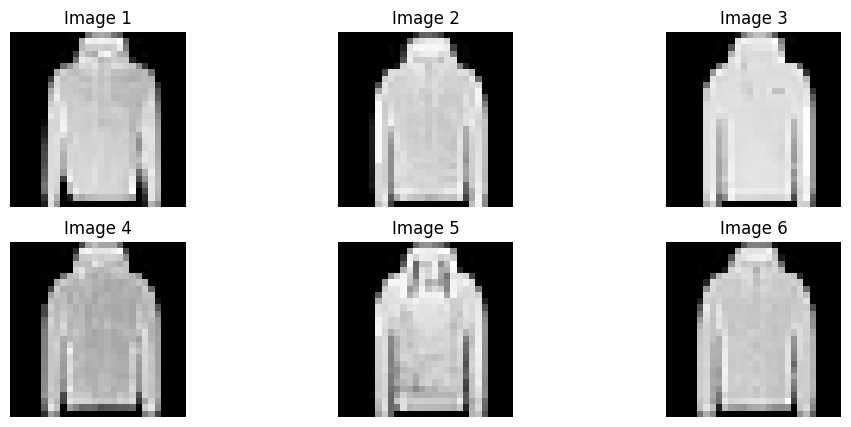

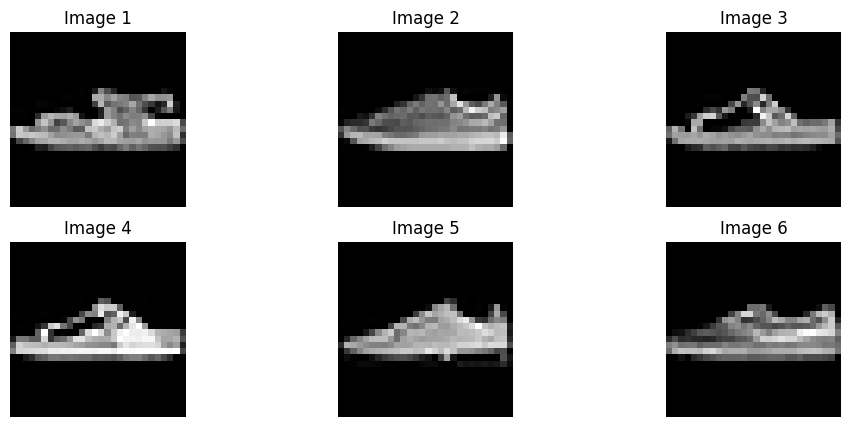

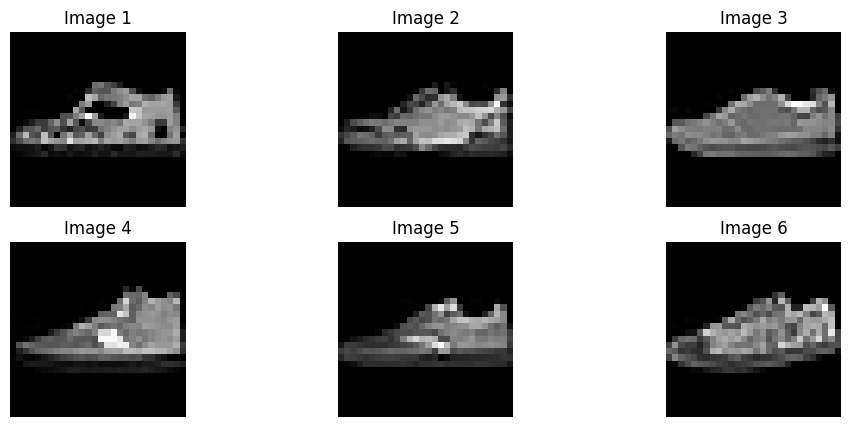

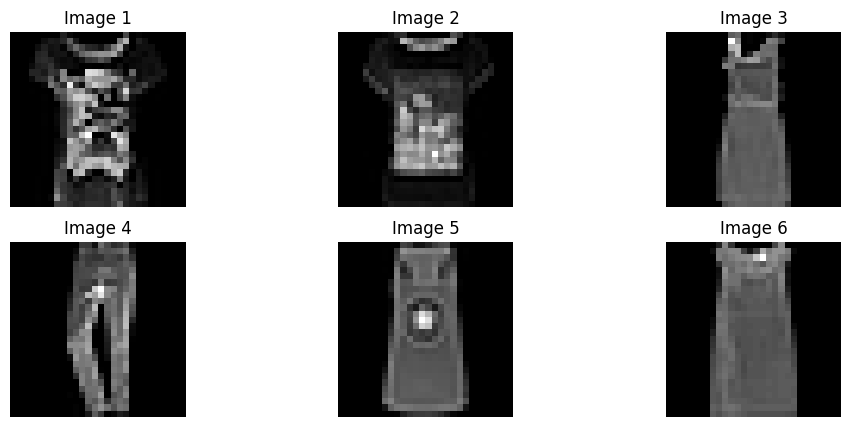

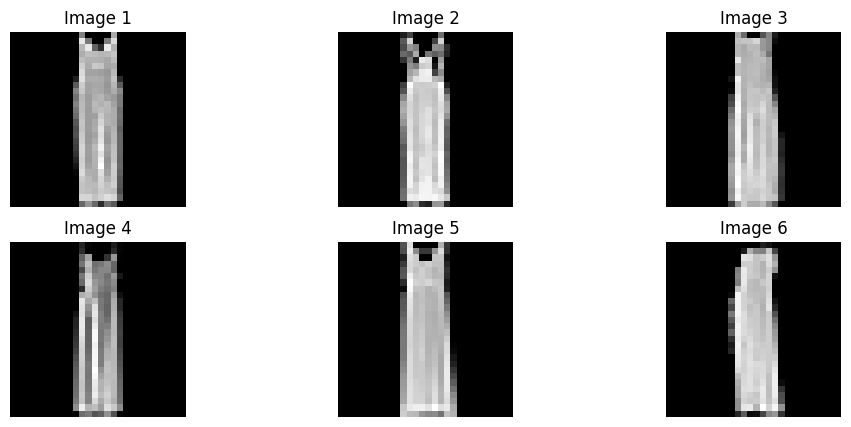

In [19]:
# Afficher les 5 premières erreurs du modèle
display_errors(knn, X_test, y_test, 5)

Les erreurs vous semblent-elles compréhensibles ? Y a-t-il des cas ambigus même pour un œil humain ? Que nous dit cela sur les limites de la distance euclidienne comme mesure de similarité entre images ?

Les erreurs observées sont instructives et révèlent plusieurs limitations importantes :

Erreurs compréhensibles :
- Pull vs Manteau (erreur 1) : confusion totalement compréhensible, même pour un humain. Les deux vêtements ont des formes très similaires (manches longues, forme générale). Les voisins sont d'ailleurs partagés entre pulls et manteaux [4 2 4 2 4].
- Sandale vs Basket (erreurs 2 et 3): confusions logiques entre deux types de chaussures. Sur l'erreur 3, TOUS les 5 voisins sont des baskets [7 7 7 7 7], ce qui explique parfaitement l'erreur. Visuellement, certaines sandales plates peuvent ressembler à des baskets basses.

Cas ambigus même pour un humain :
- T-shirt vs Robe (erreur 4) : cette erreur est plus surprenante. Le T-shirt semble avoir été confondu avec une robe, probablement à cause de l'orientation ou de la forme particulière de l'image. Les voisins mixtes [6 3 1 0 3] montrent l'ambiguïté.
- Pantalon vs Robe (erreur 5) : confusion inhabituelle , Un pantalon prédit comme robe avec des voisins majoritairement des robes [1 3 3 3 3]. Cela suggère que l'image du pantalon a une forme verticale allongée similaire à une robe.

Limites de la distance euclidienne :

La distance euclidienne mesure la similarité pixel par pixel sans comprendre la structure sémantique :
- Sensibilité au positionnement : deux vêtements identiques légèrement décalés auront une grande distance euclidienne.
- Pas de notion de forme : elle ne capture pas les caractéristiques structurelles (présence de manches, longueur, séparation pantalon/jupe).
- Sensibilité au bruit : de petites variations de pixels (plis, textures) peuvent dominer la distance au détriment des caractéristiques importantes.
- Absence de hiérarchie des caractéristiques : tous les pixels contribuent également, alors que certaines zones (col, manches, bas du vêtement) sont plus discriminantes.

Ces limites expliquent pourquoi des méthodes plus sophistiquées (réseaux de neurones convolutifs) qui apprennent des représentations hiérarchiques performent bien mieux sur ce type de tâche.